In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [3]:
data = pd.read_csv("household_power_consumption.txt", sep=";")

/var/folders/w1/684s5ms515348ms3yt5nj7_40000gn/T/ipykernel_56465/3483890989.py:1: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("household_power_consumption.txt", sep=";")


In [ ]:
df = data.copy()

In [8]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,2006-12-16 17:28:00


In [7]:
df['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'], dayfirst=True)

In [35]:
# date range (there is data from 2006 - 2010)
df["datetime"].min(), df["datetime"].max()

(Timestamp('2006-12-16 17:24:00'), Timestamp('2010-11-26 21:02:00'))

In [57]:
df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")

In [48]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,2006-12-16,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,2006-12-16 17:24:00
1,2006-12-16,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,2006-12-16 17:25:00
2,2006-12-16,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,2006-12-16 17:26:00
3,2006-12-16,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,2006-12-16 17:27:00
4,2006-12-16,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,2006-12-16 17:28:00


Text(0.5, 1.0, 'Distribution of Global Active Power')

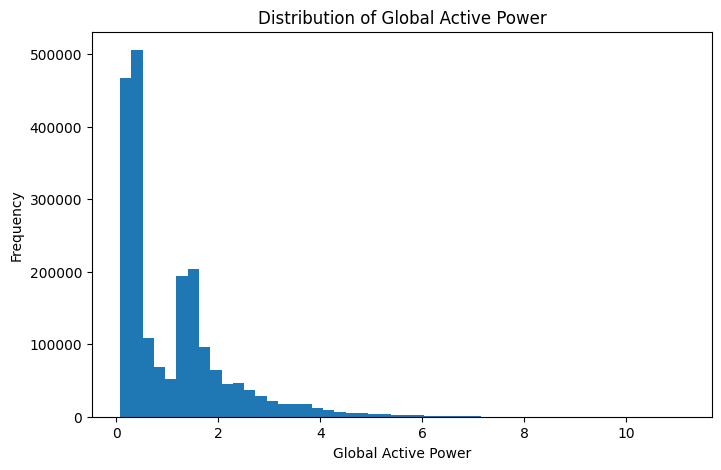

In [ ]:
# We are trying to predict Global_active_power

plt.figure(figsize=(8, 5))
plt.hist(df["Global_active_power"], bins=50)
plt.xlabel("Global Active Power")
plt.ylabel("Frequency")
plt.title("Distribution of Global Active Power")


Text(0.5, 1.0, 'Global Active Power Over Time')

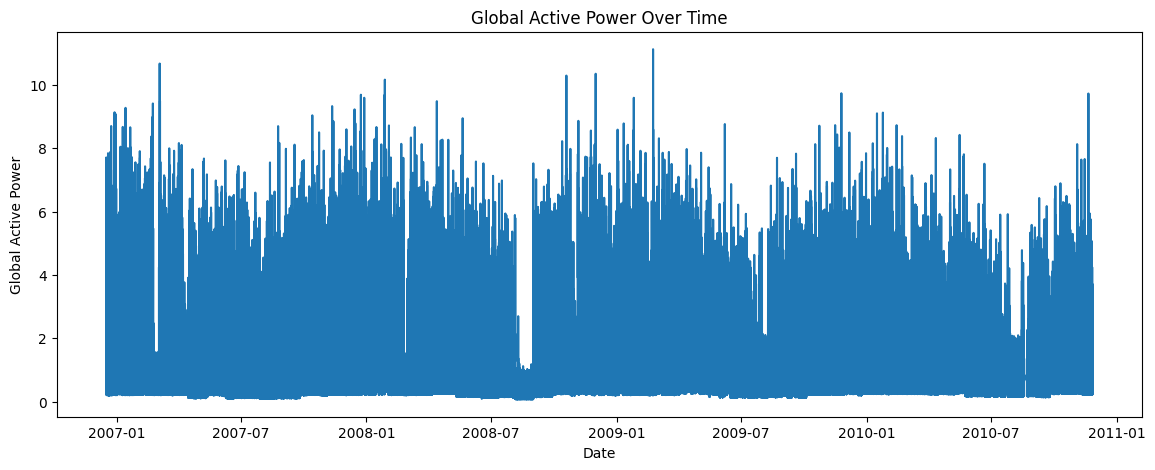

In [61]:
plt.figure(figsize=(14, 5))
plt.plot(df['datetime'], df["Global_active_power"])
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.title("Global Active Power Over Time")


Text(0.5, 1.0, 'Daily Average Power Usage')

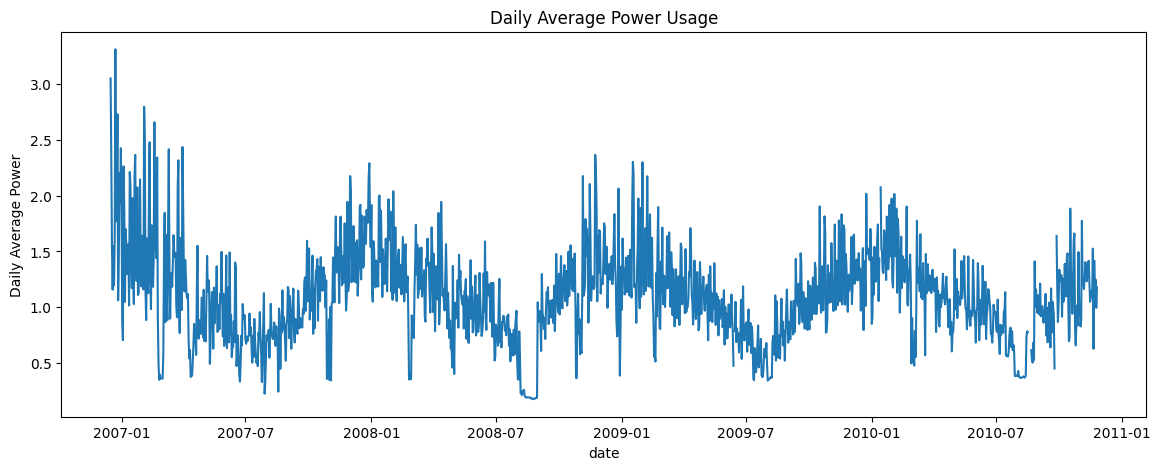

In [70]:
daily_power = df["Global_active_power"].resample("D").mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_power)
plt.xlabel("date")
plt.ylabel("Daily Average Power")
plt.title("Daily Average Power Usage")



Text(0.5, 1.0, 'Weekly Average Power Usage')

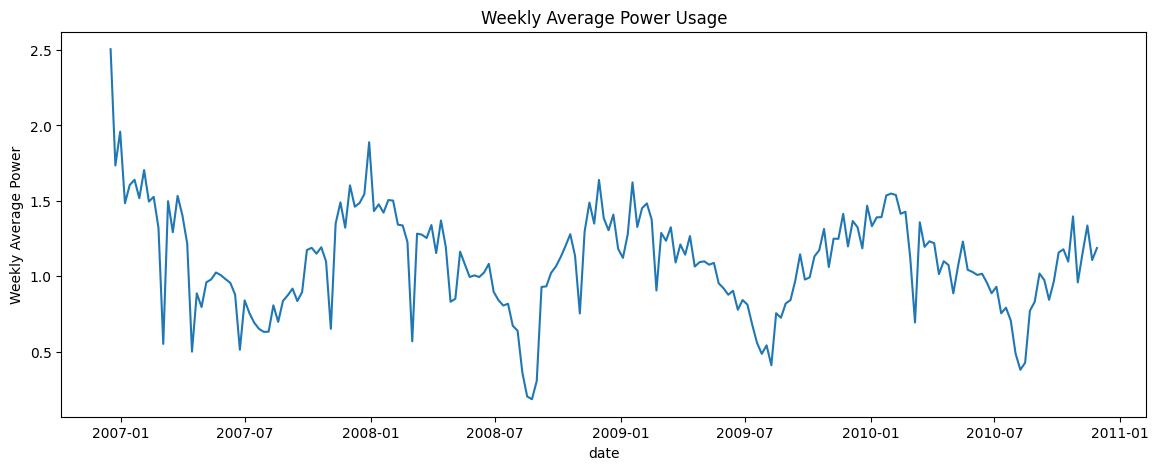

In [71]:
weekly_power = df["Global_active_power"].resample("W").mean()

plt.figure(figsize=(14, 5))
plt.plot(weekly_power)
plt.xlabel("date")
plt.ylabel("Weekly Average Power")
plt.title("Weekly Average Power Usage")

Text(0.5, 1.0, 'Monthly Average Power Usage')

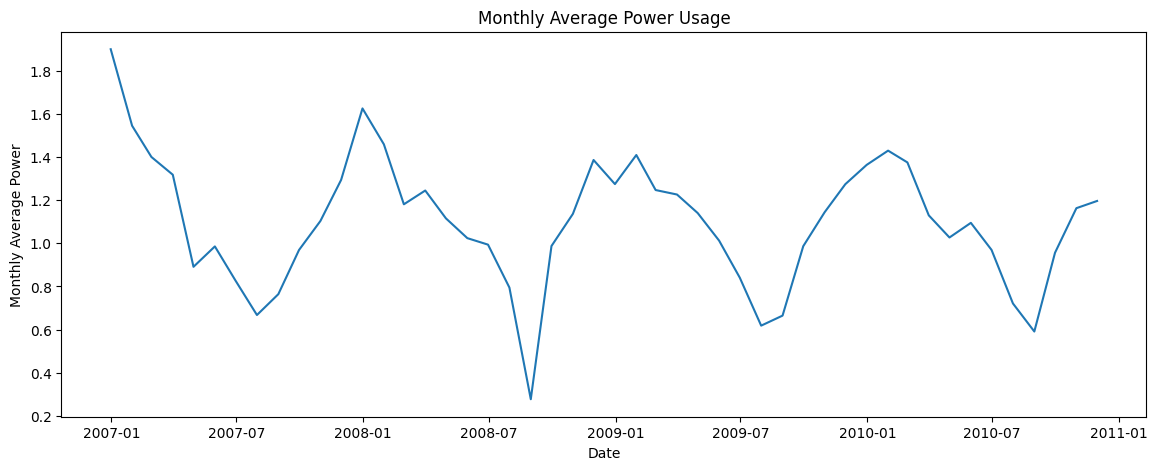

In [74]:
monthly_power = df["Global_active_power"].resample("ME").mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_power)
plt.xlabel("Date")
plt.ylabel("Monthly Average Power")
plt.title("Monthly Average Power Usage")


# based on the graph below, the average monthly power consumption is higher during winters and lower during summers

Text(0.5, 1.0, 'Average Power Usage by Hour')

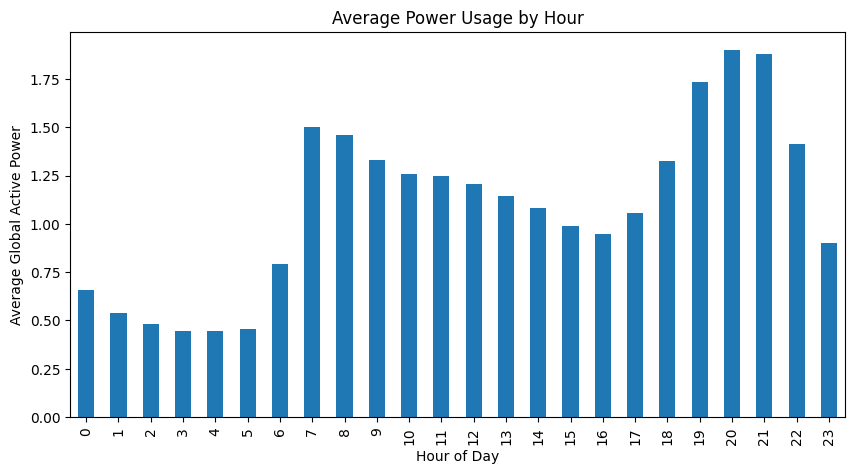

In [ ]:
# analyzing average energy consumption by the hour

df['hour'] = df.index.hour

hourly_avg = df.groupby("hour")['Global_active_power'].mean()

plt.figure(figsize=(10,5))
hourly_avg.plot(kind='bar')
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Usage by Hour")

Text(0.5, 1.0, 'Average Power Usage by Day of Week')

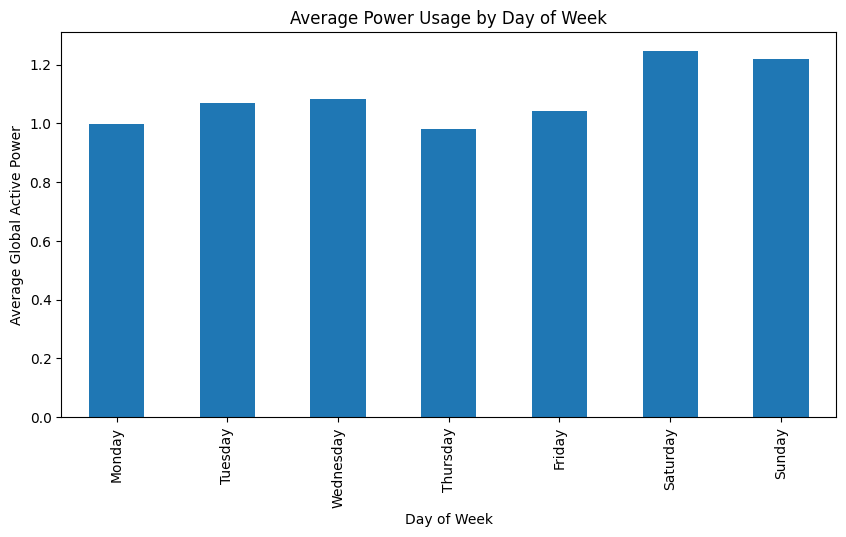

In [99]:
# day of the week pattern  - slightly higher on saturdays and sundays

df['day'] = df.index.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_of_week_avg = df.groupby('day')["Global_active_power"].mean().reindex(order)

plt.figure(figsize=(10,5))
day_of_week_avg.plot(kind='bar')
plt.xlabel("Day of Week")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Usage by Day of Week")



Text(0.5, 1.0, 'Average Power Usage by Month')

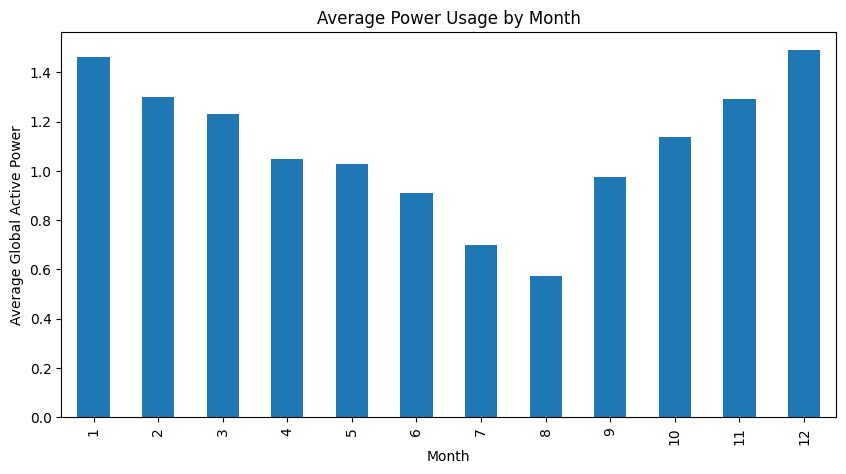

In [102]:
df['month'] = df.index.month

monthly_pattern = df.groupby('month')['Global_active_power'].mean()

plt.figure(figsize=(10,5))
monthly_pattern.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Usage by Month")

In [ ]:
sub_meter_cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

In [94]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day
datetime,,,,,,,,,,,
2006-12-16 17:24:00,2006-12-16,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,17,Saturday
2006-12-16 17:25:00,2006-12-16,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,17,Saturday
2006-12-16 17:26:00,2006-12-16,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,17,Saturday
2006-12-16 17:27:00,2006-12-16,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,17,Saturday
2006-12-16 17:28:00,2006-12-16,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,17,Saturday
